## data load


In [1]:
!python --version

Python 3.12.12


In [2]:
!pip install tensorflow==2.18.0
!pip install git+https://github.com/tensorflow/addons.git

  Using cached ml_dtypes-0.4.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (20 kB)
Using cached ml_dtypes-0.4.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.2 MB)
  Attempting uninstall: ml-dtypes
    Found existing installation: ml_dtypes 0.5.0
    Uninstalling ml_dtypes-0.5.0:
      Successfully uninstalled ml_dtypes-0.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.18.0 which is incompatible.
jax 0.7.2 requires ml_dtypes>=0.5.0, but you have ml-dtypes 0.4.1 which is incompatible.
tensorstore 0.1.78 requires ml_dtypes>=0.5.0, but you have ml-dtypes 0.4.1 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.18.0 which is incompatible.
jaxlib 0.7.2 requires ml_dtypes>=0.5.0, 

In [3]:
!pip install ml_dtypes==0.5

  Using cached ml_dtypes-0.5.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (21 kB)
Using cached ml_dtypes-0.5.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.5 MB)
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.18.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.18.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.18.0 which is incompatible.


In [4]:
import tensorflow as tf
import tensorflow_addons as tfa

print("TensorFlow version:", tf.__version__)
print("TensorFlow Addons version:", tfa.__version__)

TensorFlow version: 2.18.0
TensorFlow Addons version: 0.23.0-dev


/usr/local/lib/python3.12/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.13.0 and strictly below 2.16.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.18.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

In [5]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))

  # Then move kaggle.json into the folder where the API expects to find it.
!mkdir -p ~/.kaggle/ && mv kaggle.json ~/.kaggle/ && chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 69 bytes


In [6]:
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
covid19-radiography-database.zip: Skipping, found more recently modified local copy (use --force to force download)


In [7]:
from zipfile import ZipFile
file_name = "/content/covid19-radiography-database.zip"
with ZipFile(file_name,'r') as zip:
  zip.extractall()
  print('Done')

Done


In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import random

In [9]:
covid_path = '/content/COVID-19_Radiography_Dataset/COVID/images'
normal_path = '/content/COVID-19_Radiography_Dataset/Normal/images'

In [10]:
def load_data(path, label):
    filepaths = []
    labels = []
    for file in os.listdir(path):
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            filepaths.append(os.path.join(path, file))
            labels.append(label)
    return filepaths, labels

covid_files, covid_labels = load_data(covid_path, 1)    # 1 = COVID
normal_files, normal_labels = load_data(normal_path, 0)  # 0 = NORMAL

filepaths = covid_files + normal_files
labels = covid_labels + normal_labels

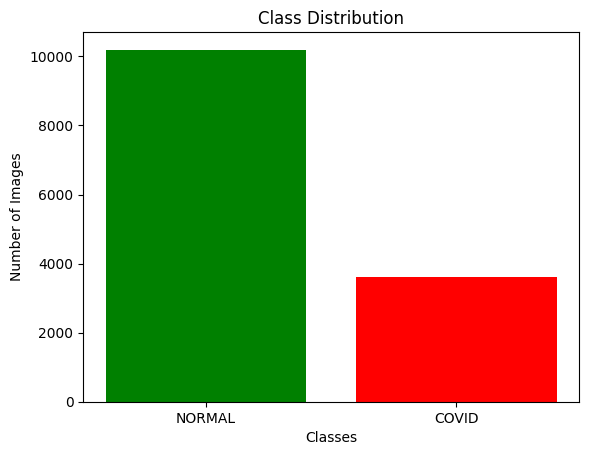

Number of Healthy images: 10192
Number of Pneumonia images: 3616


In [11]:
# Count the number of images in each class
healthy_count = len(normal_files)
pneumonia_count = len(covid_labels)

# Create a histogram
plt.bar(['NORMAL', 'COVID'], [healthy_count, pneumonia_count], color=['green', 'red'])
plt.title('Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Images')
plt.show()
# Afficher le nombre d'images dans chaque classe
print(f"Number of Healthy images: {healthy_count}")
print(f"Number of Pneumonia images: {pneumonia_count}")

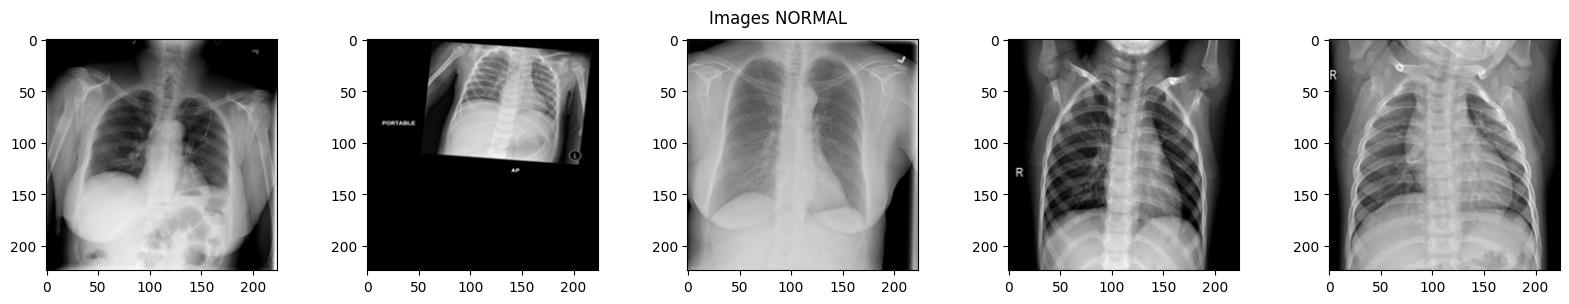

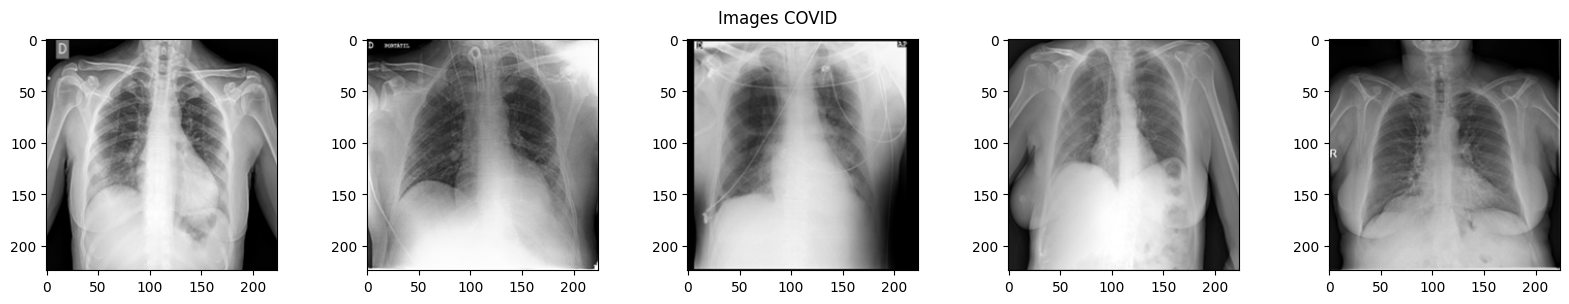

In [12]:
def display_images(filepaths, title, num_images=5, img_size=(224, 224)):
    plt.figure(figsize=(20, 3))
    plt.suptitle(title)

    for i in range(num_images):
        img_path = random.choice(filepaths)
        img = Image.open(img_path).resize(img_size)  # Redimensionner l'image
        plt.subplot(1, num_images, i+1)
        plt.imshow(img, cmap='gray')#Affiche l’image en niveaux de gris.
        plt.axis('on')

    plt.show()

display_images(normal_files, "Images NORMAL")
display_images(covid_files, "Images COVID")

# preparation

In [11]:
train_files, test_files, train_labels, test_labels = train_test_split(filepaths, labels, test_size=0.2, random_state=42, stratify=labels)

In [14]:
print(len(train_files))
print(len(test_files))

11046
2762


In [12]:
# Split the training data into training and validation sets
train_files, val_files, train_labels, val_labels = train_test_split(
    train_files, train_labels, test_size=0.1, random_state=42, stratify=train_labels
)

In [16]:
print(len(train_files))
print(len(test_files))
print(len(val_files))

9941
2762
1105


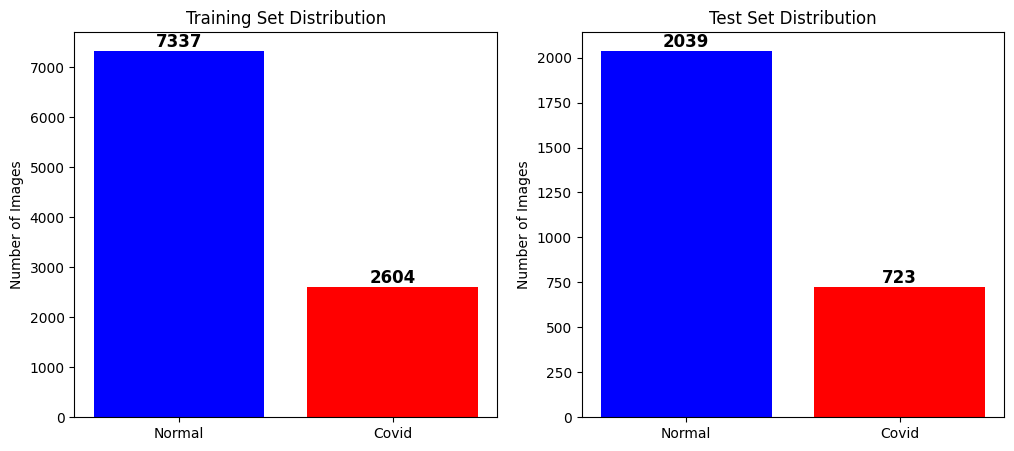

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Convert labels to NumPy array for easier processing
train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

# Count the occurrences of each class (assuming 0 = Normal, 1 = Pneumonia)
train_counts = np.bincount(train_labels)
test_counts = np.bincount(test_labels)

# Define class names
class_names = ["Normal", "Covid"]

# Plot histogram
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Training set histogram
bars_train = ax[0].bar(class_names, train_counts, color=['blue', 'red'])
ax[0].set_title("Training Set Distribution")
ax[0].set_ylabel("Number of Images")

# Test set histogram
bars_test = ax[1].bar(class_names, test_counts, color=['blue', 'red'])
ax[1].set_title("Test Set Distribution")
ax[1].set_ylabel("Number of Images")

# Add labels on top of the bars
for bar in bars_train:
    ax[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(bar.get_height())}',
               ha='center', va='bottom', fontsize=12, fontweight='bold')

for bar in bars_test:
    ax[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f'{int(bar.get_height())}',
               ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.show()

In [ ]:
#Flip horizontal aléatoire
image_path1 = '/content/chest_xray/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg'
image1 = tf.io.read_file(image_path1)  # Read the image file
image1 = tf.image.decode_jpeg(image1, channels=3)  # Decode the image into a tensor
left_right1 = tf.image.random_flip_left_right(image1)
image_path2 = '/content/chest_xray/chest_xray/train/NORMAL/IM-0115-0001.jpeg'
image2 = tf.io.read_file(image_path2)  # Read the image file
image2 = tf.image.decode_jpeg(image2, channels=3)  # Decode the image into a tensor
left_right2 = tf.image.random_flip_left_right(image2)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(pneumonia)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(left_right1.numpy().astype(int))  # Display rot1 instead of rot
plt.title('Augmented Image(pneumonia)')
plt.axis('off')

plt.show()
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(normal)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(left_right2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Augmented Image(normal)')
plt.axis('off')

plt.show()

NotFoundError: {{function_node __wrapped__ReadFile_device_/job:localhost/replica:0/task:0/device:CPU:0}} /content/chest_xray/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg; No such file or directory [Op:ReadFile]

In [ ]:
#Modification de la luminosité
image_path1 = '/content/chest_xray/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg'
image1 = tf.io.read_file(image_path1)  # Read the image file
image1 = tf.image.decode_jpeg(image1, channels=3)  # Decode the image into a tensor
bright1 = tf.image.random_brightness(image1, max_delta=0.2)
image_path2 = '/content/chest_xray/chest_xray/train/NORMAL/IM-0115-0001.jpeg'
image2 = tf.io.read_file(image_path2)  # Read the image file
image2 = tf.image.decode_jpeg(image2, channels=3)  # Decode the image into a tensor
bright2 = tf.image.random_brightness(image2, max_delta=0.2)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(pneumonia)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bright1.numpy().astype(int))  # Display rot1 instead of rot
plt.title('Augmented Image(pneumonia)')
plt.axis('off')

plt.show()
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(normal)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(bright2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Augmented Image(normal)')
plt.axis('off')

plt.show()

In [ ]:
#rotation
image_path1 = '/content/chest_xray/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg'
image1 = tf.io.read_file(image_path1)  # Read the image file
image1 = tf.image.decode_jpeg(image1, channels=3)  # Decode the image into a tensor
angles = tf.random.uniform(shape=[], minval=-0.2, maxval=0.2)  # Rotation entre -15° et 15° (en radians)
rot1 = tfa.image.rotate(image1, angles)
image_path2 = '/content/chest_xray/chest_xray/train/NORMAL/IM-0115-0001.jpeg'
image2 = tf.io.read_file(image_path2)  # Read the image file
image2 = tf.image.decode_jpeg(image2, channels=3)  # Decode the image into a tensor
angles = tf.random.uniform(shape=[], minval=-0.2, maxval=0.2)  # Rotation entre -10° et 10° (en radians)
rot2 = tfa.image.rotate(image2, angles)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(pneumonia)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rot1.numpy().astype(int))  # Display rot1 instead of rot
plt.title('Augmented Image(pneumonia)')
plt.axis('off')

plt.show()
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(normal)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(rot2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Augmented Image(normal)')
plt.axis('off')

plt.show()

In [ ]:
#zoom
image_path1 = '/content/chest_xray/chest_xray/train/PNEUMONIA/person1000_bacteria_2931.jpeg'
image1 = tf.io.read_file(image_path1)  # Read the image file
image1 = tf.image.decode_jpeg(image1, channels=3)  # Decode the image into a tensor
zoom_factor = tf.random.uniform(shape=[], minval=1.0, maxval=1.2)
original_shape = tf.shape(image1)
new_shape = tf.cast(tf.cast(original_shape[:2], tf.float32) * zoom_factor, tf.int32) # Select only height and width
image11 = tf.image.resize(image1, new_shape)
image12 = tf.image.random_crop(image11, original_shape)
image_path2 = '/content/chest_xray/chest_xray/train/NORMAL/IM-0115-0001.jpeg'
image2 = tf.io.read_file(image_path2)  # Read the image file
image2 = tf.image.decode_jpeg(image2, channels=3)  # Decode the image into a tensor
zoom_factor = tf.random.uniform(shape=[], minval=1.0, maxval=1.2)
original_shape = tf.shape(image2)
new_shape = tf.cast(tf.cast(original_shape[:2], tf.float32) * zoom_factor, tf.int32) # Select only height and width
image22 = tf.image.resize(image2, new_shape)
image13 = tf.image.random_crop(image22, original_shape)


plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image1.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(pneumonia)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image12.numpy().astype(int))  # Display rot1 instead of rot
plt.title('Augmented Image(pneumonia)')
plt.axis('off')

plt.show()
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image2.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Original Image(normal)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image13.numpy().astype(int))  # Convert to NumPy array and display
plt.title('Augmented Image(normal)')
plt.axis('off')

plt.show()

In [13]:
def create_dataset(filepaths, labels, batch_size=32, augment=False):
    def load_and_preprocess_image(filepath, label):
        image = tf.io.read_file(filepath)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, [224, 224])
        image = image / 255.0
        return image, label
          # Handle cases where image decoding fails

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))
    dataset = dataset.map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    if augment:
        def augment_image(image, label):
            angles = tf.random.uniform(shape=[], minval=-0.2, maxval=0.2)
            image = tfa.image.rotate(image, angles)
            image = tf.image.random_flip_left_right(image)
            image = tf.image.random_brightness(image, max_delta=0.2)
            # Zoom (20% zoom in)
            zoom_factor = tf.random.uniform(shape=[], minval=1.0, maxval=1.2)
            original_shape = tf.shape(image)
            new_shape = tf.cast(tf.cast(original_shape[:2], tf.float32) * zoom_factor, tf.int32) # Select only height and width
            image = tf.image.resize(image, new_shape)
            image = tf.image.random_crop(image, original_shape)
            image = tf.clip_by_value(image, 0.0, 1.0)
            # Return the image and label, regardless of augmentation
            return image, label
        dataset = dataset.map(augment_image, num_parallel_calls=tf.data.AUTOTUNE)


    dataset = dataset.cache().batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return dataset

# Créer les datasets
train_dataset = create_dataset(train_files, train_labels, augment=True)
test_dataset = create_dataset(test_files, test_labels)
val_dataset = create_dataset(val_files, val_labels)

In [ ]:
train_count = sum(1 for _ in train_dataset.unbatch())
val_count = sum(1 for _ in val_dataset.unbatch())
test_count = sum(1 for _ in test_dataset.unbatch())

print("Train samples:", train_count)
print("Validation samples:", val_count)
print("Test samples:", test_count)


In [ ]:
# Verify a few samples
for img, lbl in train_dataset.take(1):
    print("Image shape:", img.shape, "dtype:", img.dtype)
    print("Label:", lbl.numpy())
    plt.imshow(img[0])
    plt.title(f"Label: {int(lbl[0])}")
    plt.show()
    break

In [ ]:
import matplotlib.pyplot as plt

# Dictionnaire de correspondance des labels pour les deux classes
label_dict = {0: "Normal", 1: "Covid"}

# Prendre un batch d'images du dataset
for images, labels in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(min(9, len(images))):  # Afficher jusqu'à 9 images
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(f"Augmented: {label_dict[labels[i].numpy()]}")
        plt.axis("on")
    plt.show()

# VGG19

In [14]:
import tensorflow as tf
from tensorflow.keras.applications import VGG19
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Charger un modèle pré-entraîné (VGG19)
base_model = VGG19(include_top=False, input_shape=(224,224,3), weights='imagenet')


# Dégeler uniquement les 4 dernières couches convolutives
for layer in base_model.layers[:-4]:
    layer.trainable = False
for layer in base_model.layers[-4:]:
    layer.trainable = True

# Ajouter des couches personnalisées
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation='sigmoid')(x) # Changed activation to sigmoid for binary classification

# Créer le modèle final
model = Model(inputs=base_model.input, outputs=predictions)

# Compiler le modèle
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='binary_crossentropy', # Changed loss to binary_crossentropy
              metrics=['accuracy'])

# Afficher le résumé du modèle
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 20,155,969 (76.89 MB)

 Trainable params: 7,211,009 (27.51 MB)

 Non-trainable params: 12,944,960 (49.38 MB)

In [ ]:
for layer in model.layers:
   print(layer, layer.trainable== True)

**Exercice** : Écrivez un code TensorFlow/Keras pour entraîner un modèle CNN (VGG19) sur le jeu de données d’images (train_files et val_dataset) en utilisant des callbacks afin de :

-Arrêter automatiquement l’entraînement lorsque la performance sur les données de validation cesse de s’améliorer.

-Sauvegarder uniquement la version du modèle ayant obtenu la meilleure performance sur la validation.

Instructions :

- Utilisez EarlyStopping pour surveiller la perte de validation (val_loss) et restaurer les meilleurs poids.

- Utilisez ModelCheckpoint pour sauvegarder le meilleur modèle dans un fichier nommé 'best_modelVGG19.keras'.

- Entraînez le modèle sur un maximum de 50 époques avec les callbacks activés.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=3,          # Stop after 5 epochs with no improvement
    restore_best_weights=True # Restore best weights from the epoch with the lowest val_loss
)

model_checkpoint = ModelCheckpoint(
    filepath='best_modelVGG19_4.keras', # Save the best model to this file
    monitor='val_loss',      # Monitor validation loss
    save_best_only=True,      # Save only the best model
    mode='min',
    verbose=1
)

# Entraîner le modèle
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,                # Tu peux ajuster (20–50 selon dataset)
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)


Epoch 1/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step - accuracy: 0.7736 - loss: 0.4559
Epoch 1: val_loss improved from inf to 0.22601, saving model to best_modelVGG19_4.keras
311/311 ━━━━━━━━━━━━━━━━━━━━ 181s 526ms/step - accuracy: 0.7738 - loss: 0.4557 - val_accuracy: 0.9077 - val_loss: 0.2260
Epoch 2/50
311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8932 - loss: 0.2615
Epoch 2: val_loss improved from 0.22601 to 0.17498, saving model to best_modelVGG19_4.keras


In [ ]:
model.save("best_modelVGG19_4.keras")


In [ ]:
from google.colab import files
files.download("best_modelVGG19_4.keras")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
pd.DataFrame(history.history).plot()


NameError: name 'history' is not defined

In [ ]:
import matplotlib.pyplot as plt

# --- Afficher les courbes de loss et d'accuracy ---
plt.figure(figsize=(14, 5))

# === Courbe de Loss ===
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# === Courbe d'Accuracy ===
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red', linewidth=2)
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Ajuster l'espacement
plt.tight_layout()
plt.show()

In [ ]:
model = tf.keras.models.load_model('best_modelVGG19_4.keras')


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
# Get predictions on the test set
predictions = model.predict(test_dataset)
predicted_classes = (predictions > 0.5).astype("int32") # Convert probabilities to class labels

# Afficher le rapport de classification avec 4 chiffres après la virgule
print("Classification Report:")
print(classification_report(test_labels, predicted_classes, digits=4))

# Calculer et afficher les métriques globales
accuracy = accuracy_score(test_labels, predicted_classes)
precision = precision_score(test_labels, predicted_classes)
recall = recall_score(test_labels, predicted_classes)
f1 = f1_score(test_labels, predicted_classes)

print("\nGlobal Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

87/87 ━━━━━━━━━━━━━━━━━━━━ 37s 267ms/step
Classification Report:
              precision    recall  f1-score   support

           0     0.9264    0.9500    0.9380      2039
           1     0.8480    0.7870    0.8164       723

    accuracy                         0.9073      2762
   macro avg     0.8872    0.8685    0.8772      2762
weighted avg     0.9058    0.9073    0.9062      2762


Global Metrics:
Accuracy: 0.9073
Precision: 0.8480
Recall: 0.7870
F1 Score: 0.8164


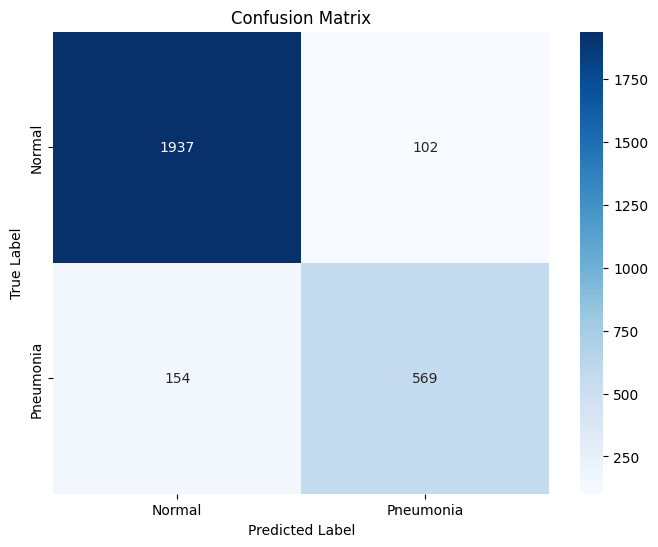

In [ ]:
# Matrice de confusion
cm = confusion_matrix(test_labels, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Pneumonia'], yticklabels=['Normal', 'Pneumonia'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# VIT

In [ ]:
#----------------vit----------------------#
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# --- Charger le modèle pré-entraîné ViT ---
base_model = tf.keras.applications.ViT16(
    include_top=False,
    input_shape=(224, 224, 3),
    weights='imagenet'
)

# --- Dégeler partiellement le modèle ---
for layer in base_model.layers[:-10]:
    layer.trainable = False
for layer in base_model.layers[-10:]:
    layer.trainable = True

# --- Ajouter des couches personnalisées ---
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
predictions = layers.Dense(1, activation='sigmoid')(x)  # binaire

model = Model(inputs=base_model.input, outputs=predictions)

# --- Compiler le modèle ---
model.compile(optimizer=Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

# --- Callbacks ---
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model_ViT.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1)

# --- Entraîner le modèle ---
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1
)


# ResNet


# XAI

In [ ]:
from google.colab import files
uploaded = files.upload()


## lime
LIME (Local Interpretable Model-agnostic Explanations) est une méthode d’explicabilité.
Elle ne regarde pas juste la prédiction, mais comment chaque partie de l’image (superpixel) contribue à la décision.

In [ ]:
import os
import keras
from keras.applications import inception_v3 as inc_net
from keras.preprocessing import image
from keras.applications.imagenet_utils import decode_predictions
from skimage.io import imread
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
print('Notebook run using keras:', keras.__version__)

Notebook run using keras: 3.10.0


In [ ]:
def transform_img_fn(path_list):
    out = []
    for img_path in path_list:
        img = image.load_img(img_path, target_size=(224, 224)) # Changed target_size to 224x224
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = inc_net.preprocess_input(x)
        out.append(x)
    return np.vstack(out)

In [ ]:
import tensorflow as tf

# Load the model from the file
model = tf.keras.models.load_model('/content/best_modelVGG19 (4).keras')

print("Model loaded successfully.")

Model loaded successfully.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predictions: [[0.9628514 ]
 [0.96819866]
 [0.01213184]]


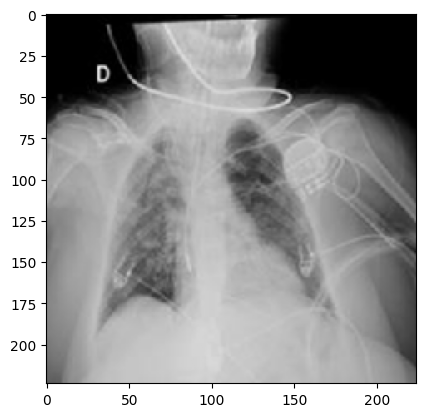

In [ ]:
images = transform_img_fn(['/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2002.png']) # Updated image paths
# I'm dividing by 2 and adding 0.5 because of how this Inception represents images
plt.imshow(images[0] / 2 + 0.5)
preds = model.predict(images)
# The decode_predictions function is for ImageNet classes, which is not suitable for this model's output.
# You can interpret the prediction directly based on the single output neuron (sigmoid activation).
print("Predictions:", preds)

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 21.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=c756e0ce36f4799be8c730db5bc186afb9c32d98417005ce52884e78b64a1fac
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
chemin= '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-1008.png'

if chemin in test_files:
    print("✅ L'image est dans la liste.")
else:
    print("❌ L'image n'est pas dans la liste.")

✅ L'image est dans la liste.


In [ ]:
covid_files = [f for f in test_files if "/COVID/images" in f]


In [ ]:
print(test_files)

['/content/COVID-19_Radiography_Dataset/Normal/images/Normal-4172.png', '/content/COVID-19_Radiography_Dataset/Normal/images/Normal-429.png', '/content/COVID-19_Radiography_Dataset/Normal/images/Normal-3453.png', '/content/COVID-19_Radiography_Dataset/Normal/images/Normal-3522.png', '/content/COVID-19_Radiography_Dataset/Normal/images/Normal-9746.png', '/content/COVID-19_Radiography_Dataset/Normal/images/Normal-3667.png', '/content/COVID-19_Radiography_Dataset/Normal/images/Normal-3379.png', '/content/COVID-19_Radiography_Dataset/Normal/images/Normal-3470.png', '/content/COVID-19_Radiography_Dataset/Normal/images/Normal-6357.png', '/content/COVID-19_Radiography_Dataset/Normal/images/Normal-7171.png', '/content/COVID-19_Radiography_Dataset/Normal/images/Normal-6574.png', '/content/COVID-19_Radiography_Dataset/Normal/images/Normal-3924.png', '/content/COVID-19_Radiography_Dataset/Normal/images/Normal-4673.png', '/content/COVID-19_Radiography_Dataset/Normal/images/Normal-1463.png', '/cont

In [ ]:
covid_files[7]

'/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2002.png'

In [ ]:
import numpy as np
from lime import lime_image
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt
from tensorflow.keras.applications.vgg19 import preprocess_input
# Assuming images are loaded as RGB
from skimage.color import gray2rgb

# Load one image from test set
img_path = '/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2002.png'
img = plt.imread(img_path)

# Convert grayscale to RGB if necessary
if img.ndim == 2:
  img = gray2rgb(img)

# Prediction (model expects [0,1] input, no preprocess_input)
img_input = np.expand_dims(img, axis=0)
pred = model.predict(img_input)[0][0]  # Scalar prob for class 1
print(f"Predicted probability for positive class: {pred}")

# Determine predicted label (0 or 1)
predicted_label = 1 if pred > 0.5 else 0
print(f"Predicted label: {predicted_label}")



1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted probability for positive class: 0.6369158029556274
Predicted label: 1


Ce que fait cette fonction :

Elle perturbe l’image (par exemple, masque des zones aléatoires).

Elle observe comment la prédiction change quand certaines parties sont masquées.

Elle attribue un poids à chaque superpixel selon son influence sur la classe.

In [ ]:
# Create LIME explainer
explainer = lime_image.LimeImageExplainer()

In [ ]:
from skimage.segmentation import slic

# Define classifier_fn for binary: returns [1-prob, prob] for classes [0,1]
# Input x is [0,1], model predicts directly on it
def classifier_fn(x):
    probs = model.predict(x)  # Shape (batch, 1)
    return np.hstack((1 - probs, probs))  # Shape (batch, 2)

# Explain the prediction with SLIC segmentation
explanation = explainer.explain_instance(
    img.astype('double'),
    classifier_fn=classifier_fn,
    top_labels=1,           # Pour visualiser les 2 classes les plus probables
    hide_color=0,
    num_samples=5000,       # Nombre d’échantillons perturbés pour l’explication
    segmentation_fn=lambda x: slic(
        x,
        n_segments=100,     # Nombre de superpixels (ajuste selon la taille de l'image)
        compactness=10,     # Plus la valeur est grande, plus les superpixels sont compacts
        sigma=1             # Lissage pour réduire le bruit
    )
)

  0%|          | 0/5000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# This cell is no longer needed as the label is set in the previous cell

### Montrer seulement les superpixels positifs (zones qui favorisent la classe) et masquer le reste



*  positive only -->Affiche uniquement les superpixels qui ont un effet positif sur la prédiction (qui augmentent la probabilité de la classe).
* num_features=5 --> Seules les 5 zones les plus importantes pour la décision “tiger” sont affichées. Si tu augmentes ce nombre, tu verras plus de zones.



(np.float64(-0.5), np.float64(298.5), np.float64(298.5), np.float64(-0.5))

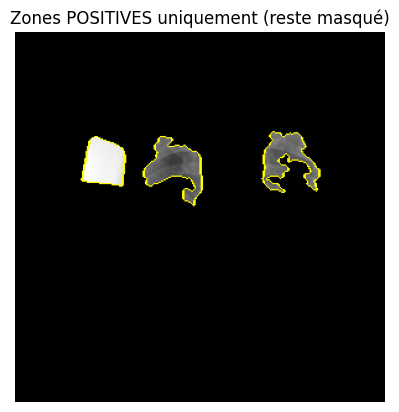

In [ ]:
# Get image and mask for the predicted label
temp, mask = explanation.get_image_and_mask(
    label=predicted_label,
    positive_only=True,
    hide_rest=True,  # Masks the rest (black if hide_color=0)
    num_features=3,  # Increase (e.g., 10) if no features are highlighted
    min_weight=0.0
)

# Normalize temp to [0,1] for display
temp = temp / temp.max() if temp.max() > 0 else temp

# Display
plt.imshow(mark_boundaries(temp, mask))
plt.title("Zones POSITIVES uniquement (reste masqué)")
plt.axis('off')

### Montrer les superpixels positifs tout en gardant le reste visible

(np.float64(-0.5), np.float64(298.5), np.float64(298.5), np.float64(-0.5))

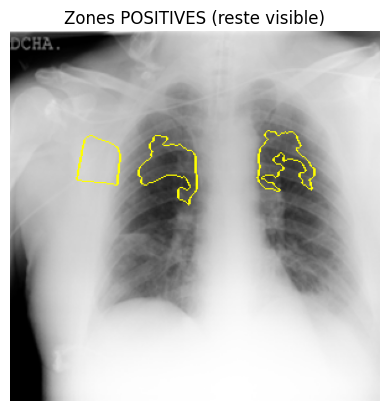

In [ ]:
# Get image and mask for the predicted label
temp, mask = explanation.get_image_and_mask(
    label=predicted_label,
    positive_only=True,
    hide_rest=False,  # Masks the rest (black if hide_color=0)
    num_features=3,  # Increase (e.g., 10) if no features are highlighted
    min_weight=0.0
)

# Normalize temp to [0,1] for display
temp = temp / temp.max() if temp.max() > 0 else temp

# Display
plt.imshow(mark_boundaries(temp, mask))
plt.title("Zones POSITIVES (reste visible)")
plt.axis('off')

### Montrer les contributions positives ET négatives

→ LIME colore les superpixels :

Vert = zones favorisant la classe (positives)

Rouge = zones qui s’y opposent (négatives)

Mask unique values: [-1  0  1]
Weights: {np.int64(7): np.float64(-0.003159563789017356), np.int64(8): np.float64(-0.0025130713439388045), np.int64(15): np.float64(-0.0020789378842603185), np.int64(3): np.float64(-0.0019490147097093657), np.int64(51): np.float64(-0.0018124937597301838), np.int64(4): np.float64(-0.001741351367613923), np.int64(85): np.float64(-0.001698546789736401), np.int64(6): np.float64(-0.001680900139791043), np.int64(66): np.float64(-0.0016487052535636515), np.int64(62): np.float64(-0.0014848561255313892), np.int64(33): np.float64(0.001442789324040515), np.int64(72): np.float64(-0.001389612648182207), np.int64(16): np.float64(-0.0013502005307078082), np.int64(20): np.float64(-0.0012964698433751934), np.int64(5): np.float64(-0.0012936510499024607), np.int64(63): np.float64(-0.0011830301738617321), np.int64(32): np.float64(0.0011717074198716198), np.int64(79): np.float64(-0.0011706566055768549), np.int64(30): np.float64(0.0011510811821450067), np.int64(26): np.float64

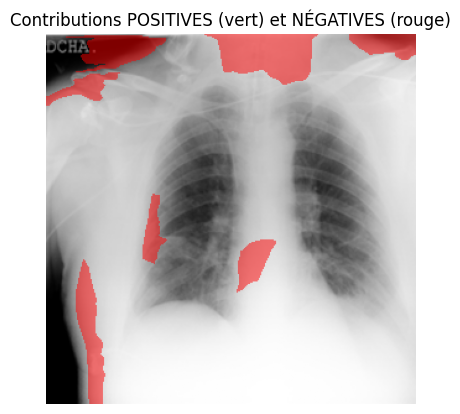

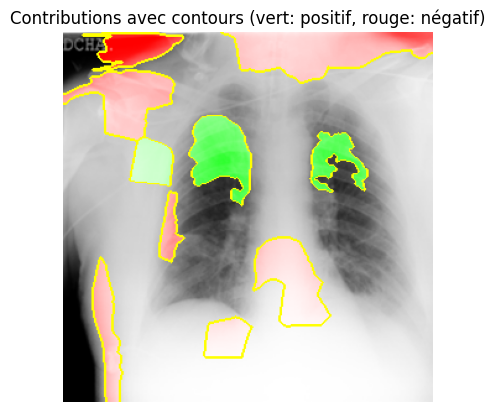

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

# Récupérer l'image et le masque pour la classe prédite
temp, mask = explanation.get_image_and_mask(
    label=predicted_label,
    positive_only=False,  # Inclut les contributions négatives
    hide_rest=False,
    num_features=20,      # Se concentrer sur les 10 superpixels les plus importants
    min_weight=0.0
)

# Obtenir les segments et les poids des superpixels
segments = explanation.segments
weights = dict(explanation.local_exp[predicted_label])  # liste -> dict pour accès rapide

# Debug : vérifier les valeurs
print("Mask unique values:", np.unique(mask))
print("Weights:", weights)

# Créer une copie de l'image pour l'overlay
overlay = img.copy()

# Colorer les superpixels selon leur contribution
for seg_id in np.unique(segments):
    weight = weights.get(seg_id, 0)
    mask_region = (segments == seg_id)

    if seg_id in [s for s, _ in sorted(weights.items(), key=lambda x: abs(x[1]), reverse=True)[:10]]:
        # Seulement les 10 superpixels les plus importants
        if weight > 0:  # Contribution positive → vert
            overlay[mask_region] = img[mask_region] * 0.5 + np.array([0, 1, 0]) * 0.5
        elif weight < 0:  # Contribution négative → rouge
            overlay[mask_region] = img[mask_region] * 0.5 + np.array([1, 0, 0]) * 0.5

# S'assurer que les valeurs sont dans [0,1]
overlay = np.clip(overlay, 0, 1)

# Affichage simple
plt.imshow(overlay)
plt.title("Contributions POSITIVES (vert) et NÉGATIVES (rouge)")
plt.axis('off')
plt.show()

# Affichage avec contours pour visualisation claire
plt.imshow(mark_boundaries(temp, mask))
plt.title("Contributions avec contours (vert: positif, rouge: négatif)")
plt.axis('off')
plt.show()


Mask unique values: [-1  0]
Weights: {np.int64(7): np.float64(-0.003159563789017356), np.int64(8): np.float64(-0.0025130713439388045), np.int64(15): np.float64(-0.0020789378842603185), np.int64(3): np.float64(-0.0019490147097093657), np.int64(51): np.float64(-0.0018124937597301838), np.int64(4): np.float64(-0.001741351367613923), np.int64(85): np.float64(-0.001698546789736401), np.int64(6): np.float64(-0.001680900139791043), np.int64(66): np.float64(-0.0016487052535636515), np.int64(62): np.float64(-0.0014848561255313892), np.int64(33): np.float64(0.001442789324040515), np.int64(72): np.float64(-0.001389612648182207), np.int64(16): np.float64(-0.0013502005307078082), np.int64(20): np.float64(-0.0012964698433751934), np.int64(5): np.float64(-0.0012936510499024607), np.int64(63): np.float64(-0.0011830301738617321), np.int64(32): np.float64(0.0011717074198716198), np.int64(79): np.float64(-0.0011706566055768549), np.int64(30): np.float64(0.0011510811821450067), np.int64(26): np.float64(0.

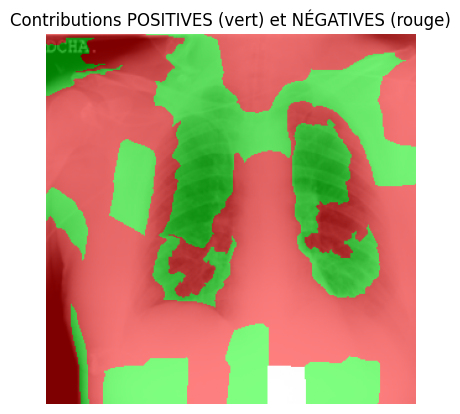

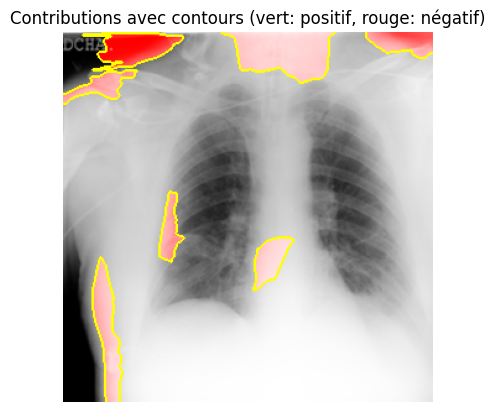

In [ ]:
# Get the image and mask with weights
temp, mask = explanation.get_image_and_mask(
    label=predicted_label,
    positive_only=False,
    hide_rest=False,
    num_features=10,
    min_weight=0.0
)

# Get the superpixel segmentation and weights from the explanation
segments = explanation.segments
weights = dict(explanation.local_exp[predicted_label]) # Convert the list of tuples to a dictionary

# Debug mask and weights
print("Mask unique values:", np.unique(mask))
print("Weights:", weights)

# Create a copy of the image for overlay
overlay = img.copy()

# Assign colors based on weights
for seg_id in np.unique(segments):
    weight = weights.get(seg_id, 0)
    mask_region = (segments == seg_id)
    if weight > 0:  # Positive contribution
        overlay[mask_region] = img[mask_region] * 0.5 + np.array([0, 1, 0]) * 0.5  # Green
    elif weight < 0:  # Negative contribution
        overlay[mask_region] = img[mask_region] * 0.5 + np.array([1, 0, 0]) * 0.5  # Red

# Ensure overlay is clipped to [0,1]
overlay = np.clip(overlay, 0, 1)

# Display
plt.imshow(overlay)
plt.title("Contributions POSITIVES (vert) et NÉGATIVES (rouge)")
plt.axis('off')
plt.show()

# Optional: Display with mark_boundaries for comparison
from skimage.segmentation import mark_boundaries
plt.imshow(mark_boundaries(temp, mask))
plt.title("Contributions avec contours (vert: positif, rouge: négatif)")
plt.axis('off')
plt.show()

### Afficher une heatmap (carte de chaleur) des poids des superpixels
Zones rouges → très importantes.

Zones bleues → peu influentes.

C’est une vue plus “quantitative” de l’importance locale.

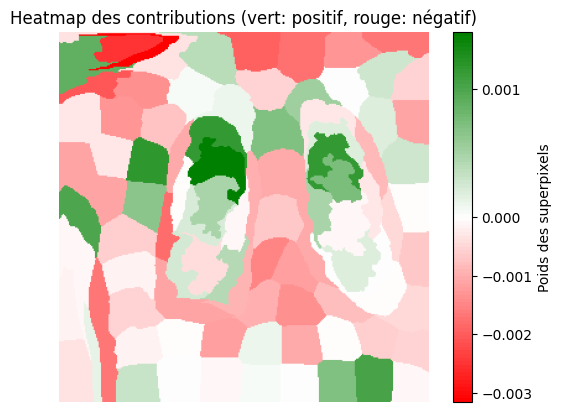

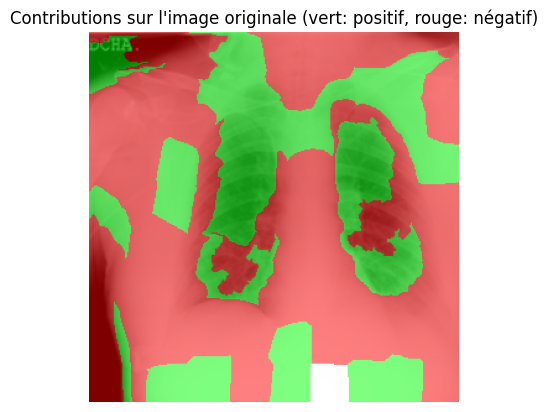

In [ ]:
# Create heatmap based on weights
weights = dict(explanation.local_exp[predicted_label])  # Use the predicted label's weights
segments = explanation.segments  # Segmentation of the image
heatmap = np.zeros(segments.shape)

# Assign the weight of each superpixel
for i in np.unique(segments):
    if i in weights:
        heatmap[segments == i] = weights[i]

# Create a custom colormap for positive (green) and negative (red) contributions
import matplotlib.colors as mcolors
colors = ['red', 'white', 'green']  # Red for negative, white for zero, green for positive
n_bins = 100  # Number of bins
cmap = mcolors.LinearSegmentedColormap.from_list('custom_cmap', colors, N=n_bins)

# Normalize heatmap values for the colormap (center at zero)
vmin = min(heatmap.min(), 0)
vmax = max(heatmap.max(), 0)
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Display heatmap with custom colormap
plt.imshow(heatmap, cmap=cmap, norm=norm)
plt.colorbar(label='Poids des superpixels')
plt.title("Heatmap des contributions (vert: positif, rouge: négatif)")
plt.axis('off')
plt.show()

# Optional: Overlay on original image for context
overlay = img.copy()
for i in np.unique(segments):
    if i in weights:
        weight = weights[i]
        mask_region = (segments == i)
        if weight > 0:  # Positive contribution
            overlay[mask_region] = img[mask_region] * 0.5 + np.array([0, 1, 0]) * 0.5  # Green
        elif weight < 0:  # Negative contribution
            overlay[mask_region] = img[mask_region] * 0.5 + np.array([1, 0, 0]) * 0.5  # Red

overlay = np.clip(overlay, 0, 1)
plt.imshow(overlay)
plt.title("Contributions sur l'image originale (vert: positif, rouge: négatif)")
plt.axis('off')
plt.show()

### autres

. Superpixel Highlighting with Original Image
. Superpixel Highlighting with Original Image
This visualization overlays the superpixels with their contribution weights directly on the original image, using green for positive and red for negative contributions. It’s similar to the overlay we used but emphasizes the segmentation boundaries.
Purpose: Shows the original image with superpixels colored based on their contribution weights.

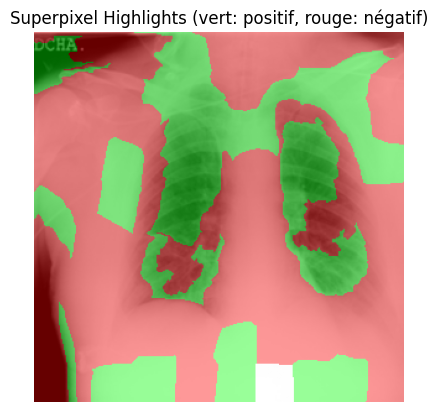

In [ ]:
# Highlight superpixels
segments = explanation.segments
weights = dict(explanation.local_exp[predicted_label])
overlay = img.copy()
for seg_id in np.unique(segments):
    if seg_id in weights:
        weight = weights[seg_id]
        mask = (segments == seg_id)
        color = np.array([0, 1, 0]) if weight > 0 else np.array([1, 0, 0])  # Green for positive, red for negative
        overlay[mask] = img[mask] * 0.6 + color * 0.4  # Blend with 40% color intensity

overlay = np.clip(overlay, 0, 1)
plt.imshow(overlay)
plt.title("Superpixel Highlights (vert: positif, rouge: négatif)")
plt.axis('off')
plt.show()

Purpose: Separates positive and negative contributions for clearer comparison.
Advantage: Useful for analyzing which regions drive the prediction in opposite directions.
Note: Adjust figsize or blend factor as needed.

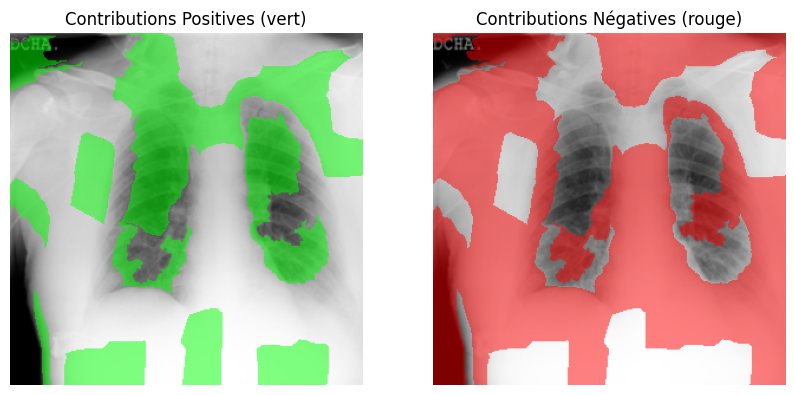

In [ ]:
# Prepare overlays
segments = explanation.segments
weights = dict(explanation.local_exp[predicted_label])
pos_overlay = img.copy()
neg_overlay = img.copy()

# Assign colors
for seg_id in np.unique(segments):
    if seg_id in weights:
        weight = weights[seg_id]
        mask = (segments == seg_id)
        if weight > 0:
            pos_overlay[mask] = img[mask] * 0.5 + np.array([0, 1, 0]) * 0.5  # Green
        elif weight < 0:
            neg_overlay[mask] = img[mask] * 0.5 + np.array([1, 0, 0]) * 0.5  # Red

pos_overlay = np.clip(pos_overlay, 0, 1)
neg_overlay = np.clip(neg_overlay, 0, 1)

# Display side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(pos_overlay)
ax1.set_title("Contributions Positives (vert)")
ax1.axis('off')
ax2.imshow(neg_overlay)
ax2.set_title("Contributions Négatives (rouge)")
ax2.axis('off')
plt.show()

## Neuro XAI

In [ ]:
loaded_model = tf.keras.models.load_model('/content/best_modelVGG19 (4).keras')


In [ ]:
for layer in model.layers:
    if 'conv' in layer.name:
        print(layer.name)

block1_conv1
block1_conv2
block2_conv1
block2_conv2
block3_conv1
block3_conv2
block3_conv3
block3_conv4
block4_conv1
block4_conv2
block4_conv3
block4_conv4
block5_conv1
block5_conv2
block5_conv3
block5_conv4


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted probability: 0.3626801
Predicted class: non-covid


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


<Figure size 600x600 with 0 Axes>

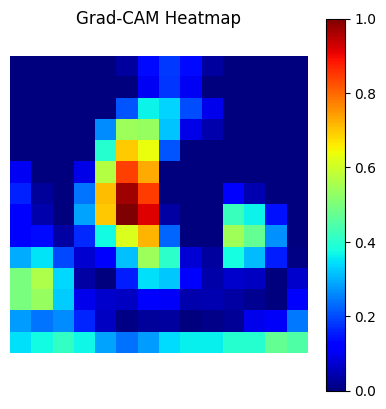

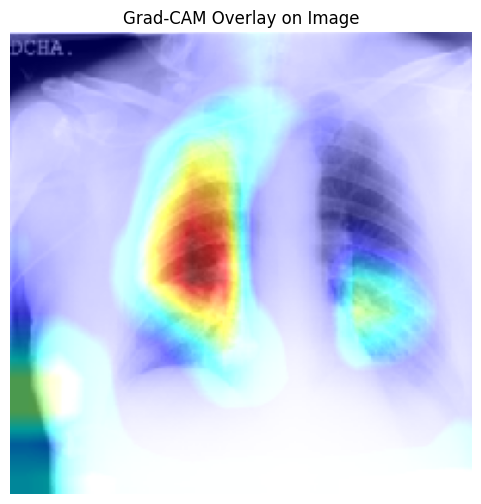

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import cv2

# Function to generate Grad-CAM heatmap
def get_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=0):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_channel = predictions[:, pred_index]  # For binary classification

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)  # ReLU
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-10)  # Normalize to [0, 1]
    return heatmap.numpy()

# Load the model
loaded_model = tf.keras.models.load_model('/content/best_modelVGG19 (4).keras')

# Load and preprocess the image
img_path =covid_files[7]
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
orig = img_array.copy()
img_array = np.expand_dims(img_array, axis=0)
img_array = img_array / 255.0  # Match training preprocessing

# Make predictions
preds = loaded_model.predict(img_array)
print('Predicted probability:', preds[0][0])
class_label = 'covid' if preds[0][0] > 0.5 else 'non-covid'
print('Predicted class:', class_label)

# Generate Grad-CAM heatmap
last_conv_layer_name = 'block5_conv4'  # Try an earlier layer
heatmap = get_gradcam_heatmap(loaded_model, img_array, last_conv_layer_name)

# Visualize the heatmap
plt.figure(figsize=(6, 6))
plt.matshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.colorbar()
plt.axis('off')
plt.show()

# Overlay the heatmap on the original image
heatmap = cv2.resize(heatmap, (orig.shape[1], orig.shape[0]))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)  # ✅ conversion
superimposed_img = heatmap * 0.6 + orig  # Increase blending factor
superimposed_img = np.clip(superimposed_img, 0, 255).astype('uint8')

plt.figure(figsize=(6, 6))
plt.imshow(superimposed_img)
plt.title("Grad-CAM Overlay on Image")
plt.axis('off')
plt.show()

### 2eme essaie

Méthodes disponibles dans NeuroXAI

LIME → Explication locale (pixels influents)

GradCAM → Carte de chaleur sur les activations du CNN

IntegratedGradients → Importance des pixels

DeepSHAP → Influence des caractéristiques


### GROK

In [ ]:
!pip install tf-keras-vis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 5.5 MB/s eta 0:00:00
  Attempting uninstall: wrapt
    Found existing installation: wrapt 2.0.0
    Uninstalling wrapt-2.0.0:
      Successfully uninstalled wrapt-2.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.18.0 requires ml-dtypes<0.5.0,>=0.4.0, but you have ml-dtypes 0.5.0 which is incompatible.
tensorflow-decision-forests 1.12.0 requires tensorflow==2.19.0, but you have tensorflow 2.18.0 which is incompatible.
tf-keras 2.19.0 requires tensorflow<2.20,>=2.19, but you have tensorflow 2.18.0 which is incompatible.
tensorflow-text 2.19.0 requires tensorflow<2.20,>=2.19.0, but you have tensorflow 2.18.0 which is incompatible.


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import tf_keras_vis
from tf_keras_vis.gradcam import Gradcam
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear
# from tf_keras_vis.utils.scores import BinaryRPS # Removed
from lime import lime_image
import shap  # Pour SHAP

# Chargez votre modèle
model = load_model('/content/best_modelVGG19 (4).keras') # Corrected model filename

# Exemple : Une image de test (prenez de test_dataset)
def get_sample_image(dataset):
    for img, lbl in dataset.take(1):
        return img[0].numpy(), lbl[0].numpy()  # img: (224,224,3), lbl: 0 ou 1

sample_img, sample_label = get_sample_image(test_dataset)
sample_img = np.expand_dims(sample_img, axis=0)  # Batch de 1

Grad-CAM (Localisation des régions critiques)

In [ ]:
# Grad-CAM sur la couche conv finale de VGG19
gradcam = Gradcam(model_modifier=ReplaceToLinear(),
                  model=model,
                  clone=True)

# Génère la carte pour la classe prédite (1: Pneumonie) using a lambda function
cam = gradcam(lambda output: output[:, 0], # Use a lambda function to get the score for the positive class
              penultimate_layer=-1)  # Dernière couche conv

# Visualisation
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_img[0])
plt.title('Image Originale')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sample_img[0])
plt.imshow(cam[0], cmap='jet', alpha=0.5)  # Superposition
plt.title('Grad-CAM (Pneumonie)')
plt.axis('off')
plt.show()

TypeError: Gradcam.__call__() missing 1 required positional argument: 'seed_input'

d. SHAP (Attributions globales)

In [ ]:
!pip install tf-keras-vis

In [ ]:
# --- 5. Préparer les Données pour SHAP ---
def get_sample_images(dataset, num_samples=5):
    images, labels = [], []
    for img, lbl in dataset.unbatch().take(num_samples):  # Unbatch pour obtenir images individuelles
        images.append(img.numpy())
        labels.append(lbl.numpy())
    return np.array(images), np.array(labels)

# Prendre 5 images de test
sample_images, sample_labels = get_sample_images(test_dataset, num_samples=5)

# --- 6. Créer une Baseline (Moyenne du Dataset) ---
# Calculer la moyenne des images d'entraînement comme baseline
def get_background_images(dataset, num_samples=100):
    images = []
    for img, _ in dataset.unbatch().take(num_samples):
        images.append(img.numpy())
    return np.mean(images, axis=0, keepdims=True)  # Image moyenne (1, 224, 224, 3)

background = get_background_images(train_dataset, num_samples=100)

# --- 7. Calculer les Valeurs SHAP avec GradientExplainer ---
explainer = shap.GradientExplainer(model, background)

# Calculer SHAP pour les 5 images
shap_values = explainer.shap_values(sample_images)

# --- 8. Visualisation Robuste des Explications SHAP ---
class_names = ['Normal', 'Pneumonie']

# Ajuster les valeurs SHAP pour la classe Pneumonie (sortie sigmoid → index 0)
shap_values = shap_values[0]  # Sortie binaire, prendre la première (et unique) sortie

# Vérifier les dimensions
print(f"Shape of sample_images: {sample_images.shape}")
print(f"Shape of shap_values: {shap_values.shape}")

# Visualisation
for i in range(len(sample_images)):
    plt.figure(figsize=(12, 5))

    # Image originale
    plt.subplot(1, 2, 1)
    plt.imshow(sample_images[i], vmin=0, vmax=1)  # Assurer la plage [0,1]
    plt.title(f'Original (Label: {class_names[int(sample_labels[i])]})')
    plt.axis('off')

    # Heatmap SHAP
    plt.subplot(1, 2, 2)
    # Normaliser les valeurs SHAP pour une meilleure visualisation
    shap_norm = shap_values[i] / (np.max(np.abs(shap_values[i])) + 1e-8)  # Éviter division par zéro
    plt.imshow(sample_images[i], vmin=0, vmax=1)
    plt.imshow(shap_norm, cmap='jet', alpha=0.5, vmin=-1, vmax=1)  # Superposition
    plt.title('SHAP Heatmap (Pneumonie)')
    plt.axis('off')

    plt.tight_layout()

    # Sauvegarder
    output_path = f'shap_explanation_{i}.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved SHAP visualization to {output_path}")

# --- 9. Afficher les Prédictions ---
predictions = model.predict(sample_images)
for i in range(len(sample_images)):
    pred = predictions[i][0]
    label = sample_labels[i]
    print(f"Image {i}: Predicted Prob (Pneumonie) = {pred:.3f}, True Label = {class_names[int(label)]}")

Shape of sample_images: (5, 224, 224, 3)
Shape of shap_values: (224, 224, 3, 1)
Saved SHAP visualization to shap_explanation_0.png
Saved SHAP visualization to shap_explanation_1.png
Saved SHAP visualization to shap_explanation_2.png
Saved SHAP visualization to shap_explanation_3.png
Saved SHAP visualization to shap_explanation_4.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Image 0: Predicted Prob (Pneumonie) = 0.022, True Label = Normal
Image 1: Predicted Prob (Pneumonie) = 0.011, True Label = Normal
Image 2: Predicted Prob (Pneumonie) = 0.204, True Label = Normal
Image 3: Predicted Prob (Pneumonie) = 0.025, True Label = Normal
Image 4: Predicted Prob (Pneumonie) = 0.018, True Label = Normal


In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg19 import preprocess_input, VGG19, decode_predictions

# --- Charger ton modèle ---
model = VGG19(weights='imagenet')  # Remplace par ton modèle entraîné

# --- 1. Charger une seule image ---
def load_image(path, target_size=(224, 224)):
    img = image.load_img(path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    preprocessed = preprocess_input(np.copy(img_array))
    return img, img_array, preprocessed

img_path = "/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2002.png"
orig_img, img_array, sample_image = load_image(img_path)

# --- 2. Fond neutre pour SHAP ---
background = np.zeros((1, 224, 224, 3))

# --- 3. Initialiser GradientExplainer ---
explainer = shap.GradientExplainer(model, background)

# --- 4. Calculer les valeurs SHAP ---
shap_values = explainer.shap_values(sample_image)

# --- 5. Prédiction du modèle ---
preds = model.predict(sample_image)
pred_class = np.argmax(preds)
class_names = ['Normal', 'COVID']  # adapte selon ton cas

# --- 6. Afficher ---
plt.figure(figsize=(10, 6))

# Image originale
plt.subplot(1, 2, 1)
plt.imshow(orig_img)
plt.title(f"Original (Predicted: {class_names[pred_class]})")
plt.axis('off')

# SHAP heatmap superposée
plt.subplot(1, 2, 2)
# shap_values est une liste : un élément par classe
shap.image_plot([shap_values[pred_class]], np.copy(img_array) / 255.0, show=False)
plt.title(f"SHAP Explanation ({class_names[pred_class]})")

plt.tight_layout()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


/tmp/ipython-input-3149325400.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


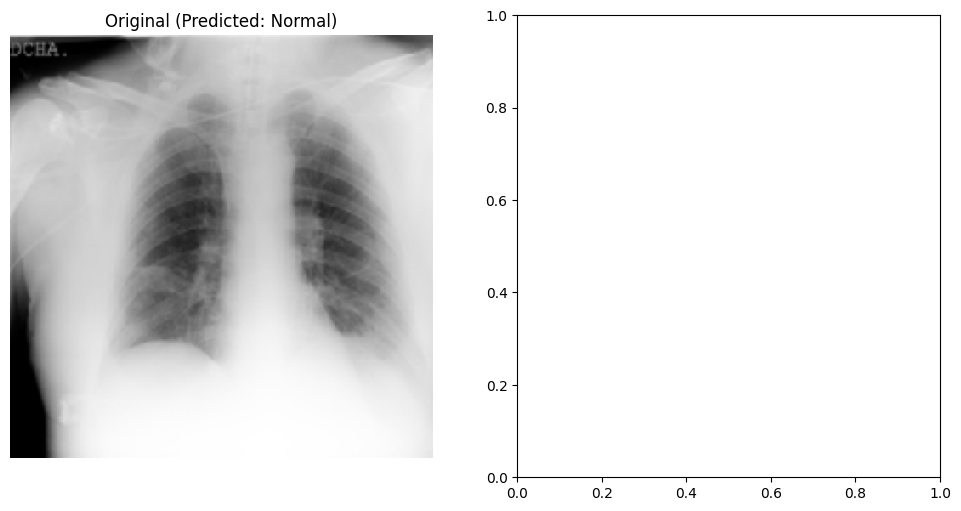

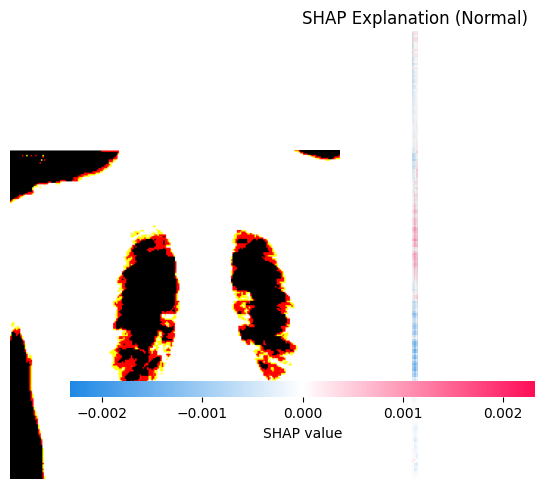

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.vgg19 import preprocess_input

# --- 1. Charger une seule image depuis un fichier ---
def load_image(path, target_size=(224, 224)):
    img = image.load_img(path, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Ajouter la dimension batch
    img_array = preprocess_input(img_array)        # Prétraitement pour VGG19 ou ton modèle
    return img_array, img

# Exemple : chemin vers ton image de test
img_path = "/content/COVID-19_Radiography_Dataset/COVID/images/COVID-2002.png"
sample_image, orig_img = load_image(img_path)

# --- 2. Fond neutre (baseline) pour SHAP ---
background = np.zeros_like(sample_image)  # Image noire de même taille

# --- 3. Initialiser GradientExplainer SHAP ---
explainer = shap.GradientExplainer(model, background)

# --- 4. Calculer les valeurs SHAP pour l'image ---
shap_values = explainer.shap_values(sample_image)

# --- 5. Prédiction du modèle pour afficher la classe ---
pred_class = np.argmax(model.predict(sample_image))

class_names = ['Normal', 'Pneumonia']  # Adapter selon tes classes

# --- 6. Visualisation ---
plt.figure(figsize=(12, 6))

# Image originale
plt.subplot(1, 2, 1)
plt.imshow(orig_img)
plt.title(f'Original (Predicted: {class_names[pred_class]})')
plt.axis('off')

# Heatmap SHAP pour la classe prédite
plt.subplot(1, 2, 2)
shap.image_plot([shap_values[pred_class]], sample_image, show=False)
plt.title(f'SHAP Explanation ({class_names[pred_class]})')
plt.axis('off')

plt.tight_layout()
plt.show()


In [ ]:
#Tester d'autres modèles de deep learning ViT, CNN... en utilisant le fine tuning

In [ ]:
# --- 5. Préparer les Données pour SHAP ---
def get_sample_images(dataset, num_samples=5):
    images, labels = [], []
    for img, lbl in dataset.unbatch().take(num_samples):
        images.append(img.numpy())
        labels.append(lbl.numpy())
    return np.array(images), np.array(labels)

# Prendre 5 images de test
sample_images, sample_labels = get_sample_images(test_dataset, num_samples=5)

# --- 6. Créer une Baseline (Image Normale) ---
# Utiliser une image normale comme baseline (première image normale)
normal_image_path = normal_files[0]  # Première image "Normal"
normal_image = tf.io.read_file(normal_image_path)
normal_image = tf.image.decode_image(normal_image, channels=3, expand_animations=False)
normal_image = tf.image.resize(normal_image, [224, 224])
normal_image = normal_image / 255.0
background = tf.expand_dims(normal_image, axis=0).numpy()

# --- 7. Calculer les Valeurs SHAP ---
explainer = shap.GradientExplainer(model, background)
shap_values = explainer.shap_values(sample_images)

# Vérifier les dimensions
print(f"Shape of sample_images: {sample_images.shape}")  # Devrait être (5, 224, 224, 3)
print(f"Shape of shap_values: {np.array(shap_values).shape}")  # Devrait être (5, 224, 224, 3, 1)

# --- 8. Visualisation Robuste ---
class_names = ['Normal', 'Pneumonie']

for i in range(len(sample_images)):
    plt.figure(figsize=(12, 5))

    # Image originale
    plt.subplot(1, 2, 1)
    plt.imshow(sample_images[i], vmin=0, vmax=1)
    plt.title(f'Original (Label: {class_names[int(sample_labels[i])]})')
    plt.axis('off')

    # Heatmap SHAP
    plt.subplot(1, 2, 2)
    shap_image = shap_values[i]  # (224, 224, 3, 1)
    # Remove the extra dimension for visualization
    shap_image = np.squeeze(shap_image) # Add this line
    if shap_image.shape != (224, 224, 3):
        print(f"Warning: Reshaping SHAP values for image {i}")
        shap_image = np.mean(shap_image, axis=2)  # Réduire à (224, 224) si nécessaire
        shap_image = np.repeat(shap_image[:, :, np.newaxis], 3, axis=2)  # Ajouter la 3e dimension

    # Normaliser pour visualisation
    shap_norm = shap_image / (np.max(np.abs(shap_image)) + 1e-8)
    plt.imshow(sample_images[i], vmin=0, vmax=1)
    plt.imshow(shap_norm, cmap='jet', alpha=0.5, vmin=-1, vmax=1)
    plt.title('SHAP Heatmap (Pneumonie)')
    plt.axis('off')

    plt.tight_layout()
    output_path = f'shap_explanation_{i}.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"Saved SHAP visualization to {output_path}")

# --- 9. Afficher les Prédictions ---
predictions = model.predict(sample_images)
for i in range(len(sample_images)):
    pred = predictions[i][0]
    label = sample_labels[i]
    print(f"Image {i}: Predicted Prob (Pneumonie) = {pred:.3f}, True Label = {class_names[int(label)]}")

Shape of sample_images: (5, 224, 224, 3)
Shape of shap_values: (5, 224, 224, 3, 1)


Saved SHAP visualization to shap_explanation_0.png


Saved SHAP visualization to shap_explanation_1.png


Saved SHAP visualization to shap_explanation_2.png


Saved SHAP visualization to shap_explanation_3.png
Saved SHAP visualization to shap_explanation_4.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Image 0: Predicted Prob (Pneumonie) = 0.022, True Label = Normal
Image 1: Predicted Prob (Pneumonie) = 0.011, True Label = Normal
Image 2: Predicted Prob (Pneumonie) = 0.204, True Label = Normal
Image 3: Predicted Prob (Pneumonie) = 0.025, True Label = Normal
Image 4: Predicted Prob (Pneumonie) = 0.018, True Label = Normal
